# 🟩 추가 학습: 컴퓨터의 작은 오차와 최적화의 조건

## 🟢 1. 중심차분의 간격을 무조건 줄이면 안 되는 이유

중심차분의 절단 오차는 부드러운 함수에서 대략 $O(h^2)$다. 하지만 h가 너무 작으면 비슷한 두 부동소수점 수를 빼며 정확한 자릿수가 사라진다. 이를 상쇄 오차라고 부른다.

실험 함수는 $f(x)=\sin x$다. $x^2$만 사용하면 중심차분의 절단 오차가 상쇄되어 일반적인 현상을 충분히 보여주지 못한다.

In [1]:
from pathlib import Path  # 프로젝트 폴더를 찾는다.
import sys  # 모듈 검색 위치를 설정한다.
import numpy as np  # 수학 계산을 직접 수행한다.
ROOT = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent  # 루트 또는 notebooks 폴더에서 실행한다.
assert (ROOT / "src").is_dir(), "Run from project root or notebooks folder."  # 실행 위치를 검사한다.
sys.path.insert(0, str(ROOT))  # 프로젝트 모듈을 불러올 수 있게 한다.
np.random.seed(42)  # 같은 난수로 재현한다.
np.set_printoptions(precision=10, suppress=True)  # 중간값을 충분한 자리수로 보여준다.

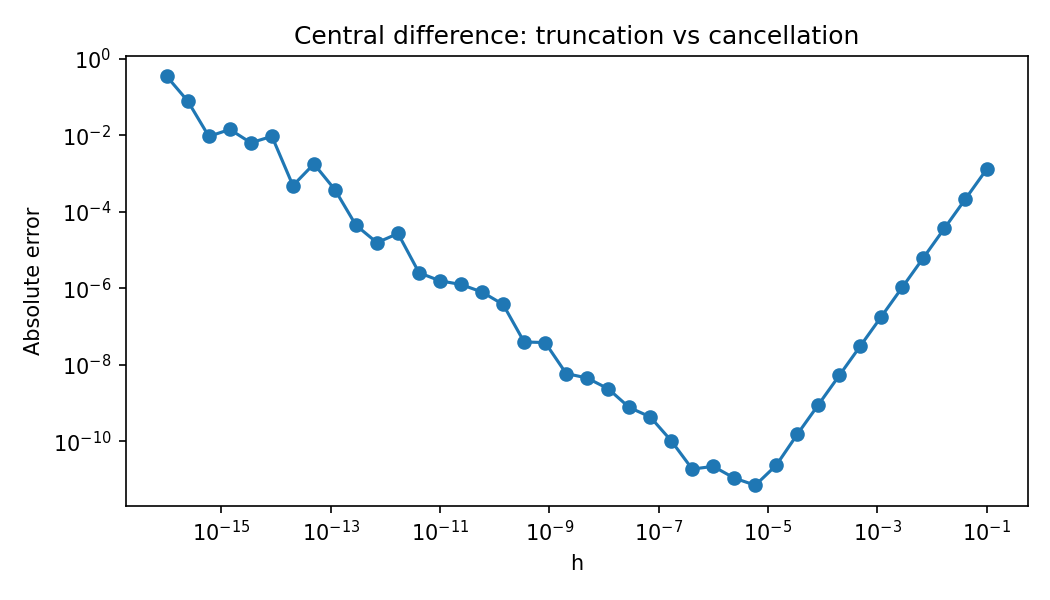

Best sampled h: 5.878016072274912e-06 error: 7.014167024976814e-12


In [2]:
import matplotlib  # 그래프 출력 도구를 설정한다.
matplotlib.use("Agg")  # 화면 없이 PNG를 만든다.
import matplotlib.pyplot as plt  # 오차 그래프를 그린다.
from IPython.display import Image, display  # 그림을 노트북에 표시한다.
from src.calculus import central_difference  # 직접 구현한 미분을 가져온다.
from src.visualization import save_figure  # 그림 저장과 닫기를 가져온다.
hs = np.logspace(-1, -16, 40)  # 큰 간격부터 매우 작은 간격까지 만든다.
errors = np.array([abs(central_difference(np.sin, 0.7, h) - np.cos(0.7)) for h in hs])  # 실제 미분과의 차이를 잰다.
figure, axis = plt.subplots(figsize=(7, 4))  # 오차 그림을 준비한다.
axis.loglog(hs, np.maximum(errors, 1e-18), "o-")  # 오차를 두 로그 축에 그린다.
axis.set(xlabel="h", ylabel="Absolute error", title="Central difference: truncation vs cancellation")  # 축과 실험 뜻을 표시한다.
save_figure(figure, ROOT / "outputs" / "finite_difference_errors.png")  # PNG를 저장한다.
display(Image(filename=str(ROOT / "outputs" / "finite_difference_errors.png")))  # 오차 그림을 노트북에 넣는다.
print("Best sampled h:", hs[np.argmin(errors)], "error:", errors.min())  # 이번 환경에서의 최선 간격을 보여준다.

## 🟢 2. 학습률의 진짜 안정 조건

원형 함수는 $\nabla f=(2x,2y)$이므로 $x_{t+1}=(1-2\eta)x_t$다. $|1-2\eta|<1$일 때 수렴한다. 따라서 $0<\eta<1$이다.

타원형 함수는 $x_{t+1}=(1-2\eta)x_t$, $y_{t+1}=(1-20\eta)y_t$다. 두 좌표가 함께 수렴하려면 $0<\eta<0.1$이다.

일반적인 양의 정부호 이차 함수에서는 $0<\eta<2/\lambda_{max}(H)$이다. 여기서 H는 Hessian(헤시안), 즉 2차 편미분 행렬이다. 조건수는 가장 큰 곡률을 가장 작은 곡률로 나눈 값이다. 이번 타원형 함수의 조건수는 $20/2=10$이다.

같은 `lr=0.05, beta=0.9` 실험에서 Momentum이 항상 빠르지는 않다. 곡률 2와 20을 알고 있는 추가 실험은 다음 heavy-ball 설정을 사용한다.

$$\eta=\frac{4}{(\sqrt{20}+\sqrt{2})^2},\quad\beta=\left(\frac{\sqrt{20}-\sqrt{2}}{\sqrt{20}+\sqrt{2}}\right)^2$$

이 설정은 이번 양의 정부호 이차 함수의 곡률 정보를 사용한다. 모든 신경망에 그대로 적용하는 규칙이 아니다. 최초 반경 진입과 마지막까지 반경을 유지하는 단계도 구별한다.

In [3]:
from src.calculus import quadratic_gradient, quadratic_hessian  # 기울기와 곡률을 가져온다.
from src.optimizer import Momentum, VanillaGD, newton_optimize, optimize  # 직접 구현한 방법을 가져온다.
from src.experiments import path_summary  # 최초 진입과 지속 수렴을 구별한다.
gradient = lambda p: quadratic_gradient(p, 10)  # 타원형 함수의 기울기를 정한다.
lr = 4 / (np.sqrt(20) + np.sqrt(2)) ** 2  # 곡률에 맞춘 학습률을 계산한다.
beta = ((np.sqrt(20) - np.sqrt(2)) / (np.sqrt(20) + np.sqrt(2))) ** 2  # 곡률에 맞춘 관성을 계산한다.
for name, optimizer in [("GD", VanillaGD(0.05)), ("Momentum beta=0.9", Momentum(0.05, 0.9)), ("Tuned Momentum", Momentum(lr, beta))]:  # 세 설정을 비교한다.
    path = optimize(gradient, [5, 5], optimizer, 300)  # 동일한 시작점과 반복 횟수를 사용한다.
    print(name, path_summary(path, 10))  # 최초 진입과 지속 진입 단계를 보여준다.
newton_path = newton_optimize(gradient, lambda p: quadratic_hessian(p, 10), [5, 5])  # 정확한 Hessian을 사용한다.
print("Newton:", newton_path[-1])  # 한 단계 결과를 보여준다.
np.testing.assert_allclose(newton_path[-1], [0, 0], atol=1e-12)  # 최솟값에 도달했는지 확인한다.

GD {'final_point': [9.369638519423942e-14, 0.0], 'final_radius': 9.369638519423942e-14, 'final_loss': 8.779012598467289e-27, 'first_hit': 38, 'sustained_hit': 38}
Momentum beta=0.9 {'final_point': [-4.4438003831979416e-07, -7.722893957866738e-07], 'final_radius': 8.910132037751447e-07, 'final_loss': 6.161782726902559e-12, 'first_hit': 65, 'sustained_hit': 80}
Tuned Momentum {'final_point': [3.427019329215826e-83, 1.0786135524066384e-82], 'final_radius': 1.1317472377980239e-82, 'final_loss': 1.175151656918087e-163, 'first_hit': 11, 'sustained_hit': 11}
Newton: [0. 0.]


## 🟢 3. Adam과 Newton의 장점과 한계

Adam = Adaptive Moment Estimation(적응적 모멘트 추정). RMSProp = Root Mean Square Propagation(제곱평균제곱근 전파).

$$m_t=\beta_1m_{t-1}+(1-\beta_1)g_t,\quad v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2$$

$$\hat m_t=\frac{m_t}{1-\beta_1^t},\quad\hat v_t=\frac{v_t}{1-\beta_2^t},\quad\theta_{t+1}=\theta_t-\eta\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}$$

각 좌표의 기울기 크기에 맞춰 이동을 조절한다. 그러나 이 작은 결정적 함수에서 GD보다 반드시 빠르지는 않다. 그림의 학습률을 확인하고 비교해야 한다.

Newton Method(뉴턴 방법)는 $H\Delta=g$를 풀고 $\theta\leftarrow\theta-\Delta$로 이동한다. 정확한 양의 정부호 이차 함수에서는 한 번에 최솟값을 구한다. 일반 함수에서는 Hessian 계산 비용, 특이 행렬, 음의 곡률, 큰 이동 때문에 실패할 수 있다. 감쇠 또는 line search(선 탐색)가 추가로 필요할 수 있다.

## 🟢 4. Power Iteration과 SVD에서 빠뜨리기 쉬운 조건

- Power Iteration(거듭제곱 반복법)은 일반적으로 절댓값이 가장 큰 고유값을 찾는다. 음의 지배 고유값은 수치상 가장 큰 고유값과 다를 수 있다.
- 지배 고유값이 유일하고 시작 벡터에 그 방향 성분이 있어야 한다. 예를 들어 `diag(5,2)`에서 `[0,1]`로 시작하면 반복만으로 `[1,0]` 성분을 만들 수 없다.
- 구현은 실수 대칭 행렬을 대상으로 한다. 복소 고유값을 갖는 일반 행렬은 범위 밖이다.
- 고유벡터 v와 -v는 같은 방향이다. 그대로 빼지 않고 내적의 절댓값으로 비교한다.
- SVD = Singular Value Decomposition(특이값 분해). $A_k=U_k\Sigma_kV_k^T$에서 중요한 방향 k개만 남긴다.
- 이미지가 m×n이면 저장할 실수 개수는 원본 mn개, 분해 결과 k(m+n+1)개다. 높은 k는 원본보다 저장량이 많을 수 있다.
- 위 저장량 비교는 같은 실수 자료형의 원소 개수 기준이다. PNG 파일의 실제 byte 크기와 같지 않다.

## 🟢 5. 더 읽을 원문

- [NumPy SVD 문서](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html)
- [Adam 원 논문](https://arxiv.org/abs/1412.6980)
- [Stanford 최적화 강의: gradient와 Newton](https://web.stanford.edu/~boyd/cvxbook/)

다음 학습 과제: 선 탐색, 정규화, 배치 역전파, Jacobian-vector product(야코비안과 벡터의 곱), 계산 그래프 순으로 확장한다.